# 08 — Time-Series Forecasting & Walk-Forward Model Validation
**Project:** AI-Based Urban Change & Environmental Risk Intelligence for Chittoor District, AP  
**Stage:** Predictive Modeling, Backtesting & Uncertainty Quantification  

### Objectives:
1. Implement chronological walk-forward rolling-origin backtesting across 4 out-of-sample years (2022 to 2025).
2. Objectively benchmark candidate models:
   - Naive Persistence Baseline ($y_{t-1}$)
   - Historical Expanding Mean
   - 2-Year Moving Average
   - Holt's Linear Exponential Smoothing
   - OLS Linear Trend Extrapolation
3. Evaluate out-of-sample metrics: Mean Absolute Error (MAE), RMSE, MAPE.
4. Generate the 1-year-ahead 2026 forecast with Student's $t$ 95% analytical prediction intervals.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))

df_master = pd.read_csv(project_root / "data" / "processed" / "Chittoor_Master_Research_Dataset_2016_2025.csv")
df_master.sort_values("year", inplace=True)
df_master.reset_index(drop=True, inplace=True)

df_comp = pd.read_csv(project_root / "outputs" / "tables" / "forecast_model_comparison.csv")
df_fc = pd.read_csv(project_root / "outputs" / "tables" / "builtup_forecast_2026.csv")

## 1. Walk-Forward Cross-Validation Results
Review model comparison table across expanding windows:
- Training: 2016 to $T-1$
- Test: $T \in [2022, 2023, 2024, 2025]$

In [2]:
print("=== Walk-Forward Backtesting Evaluation (Built-Up Area) ===")
bu_models = df_comp[df_comp["target"].str.contains("Built-Up Area", case=False)]
bu_models[["model", "mae", "rmse", "mape_pct", "improvement_mae_pct", "status"]]

=== Walk-Forward Backtesting Evaluation (Built-Up Area) ===


,model,mae,rmse,mape_pct,improvement_mae_pct,status
0,Last-Value Persistence (y_{t-1}),14.4368,16.1324,6.06,0.0,Baseline Anchor
1,Historical Expanding Mean (y_{1:t-1}),49.8296,50.7731,20.23,-245.2,Inferior to Baseline
2,2-Year Moving Average,21.0834,22.5477,8.68,-46.0,Inferior to Baseline
3,OLS Linear Trend Extrapolation,8.0713,10.2422,3.30,44.1,Superior to Baseline
4,"Holt's Linear Exponential Smoothing (alpha=0.8, beta=0.2)",8.2640,8.8351,3.39,42.8,Superior to Baseline


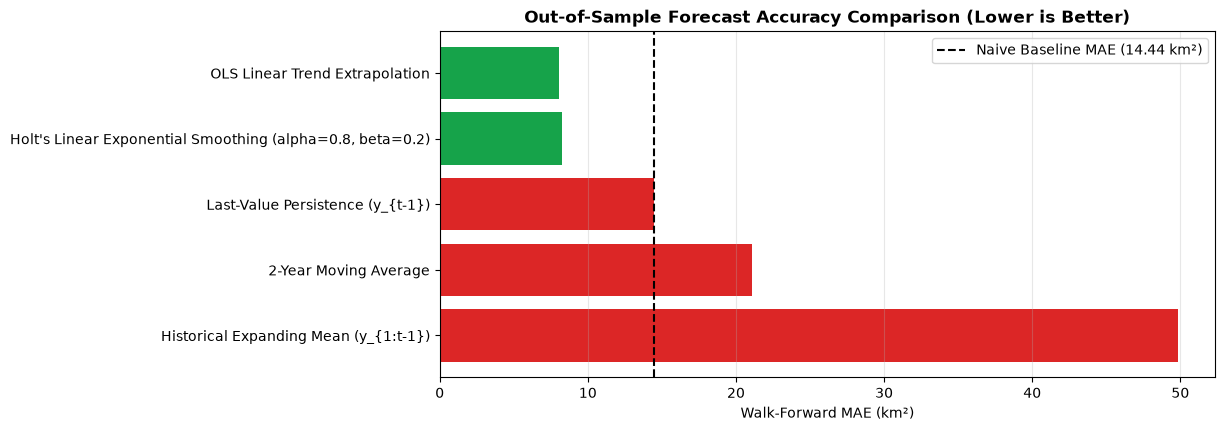

In [3]:
plt.figure(figsize=(10, 4.5))
models_sorted = bu_models.sort_values("mae")
colors = ["#16a34a" if imp > 0 else "#dc2626" for imp in models_sorted["improvement_mae_pct"]]
plt.barh(models_sorted["model"][::-1], models_sorted["mae"][::-1], color=colors[::-1])
plt.axvline(14.4368, color="black", linestyle="--", label="Naive Baseline MAE (14.44 km²)")
plt.xlabel("Walk-Forward MAE (km²)")
plt.title("Out-of-Sample Forecast Accuracy Comparison (Lower is Better)", fontsize=12, fontweight="bold")
plt.grid(True, alpha=0.3, axis="x")
plt.legend()
plt.show()

## 2. 2026 Built-Up Extent Forecast with 95% Prediction Interval
Compute point forecast and analytical Student's $t$ interval (df = 8):
$$\hat{y}_{2026} \pm t_{0.025, N-2} \cdot s_e \sqrt{1 + \frac{1}{N} + \frac{(x_* - \bar{x})^2}{\sum (x_i - \bar{x})^2}}$$

In [4]:
print("=== Authoritative 2026 Forecast Verification ===")
for _, r in df_fc.iterrows():
    print(f"Target: {r['target']}")
    print(f" - Baseline (2025): {r['historical_last_value']:.2f} km²")
    print(f" - 2026 Forecast: {r['point_forecast']:.2f} km² [{r['lower_95']:.2f}, {r['upper_95']:.2f}] km²")
    print(f" - Model: {r['model']} (MAE = {r['validation_mae']:.2f} km², Baseline MAE = {r['baseline_mae']:.2f} km²)")
    print(f" - Out-of-Sample Improvement: +{r['improvement_percent']:.1f}%\n")

=== Authoritative 2026 Forecast Verification ===
Target: Total Built-Up Area (km²)
 - Baseline (2025): 259.21 km²
 - 2026 Forecast: 270.32 km² [250.02, 290.62] km²
 - Model: OLS Linear Trend Extrapolation (MAE = 8.07 km², Baseline MAE = 14.44 km²)
 - Out-of-Sample Improvement: +44.1%

Target: Strong Built-Up Core (km²)
 - Baseline (2025): 69.01 km²
 - 2026 Forecast: 70.31 km² [64.75, 75.87] km²
 - Model: OLS Linear Trend Extrapolation (MAE = 3.10 km², Baseline MAE = 4.97 km²)
 - Out-of-Sample Improvement: +37.6%



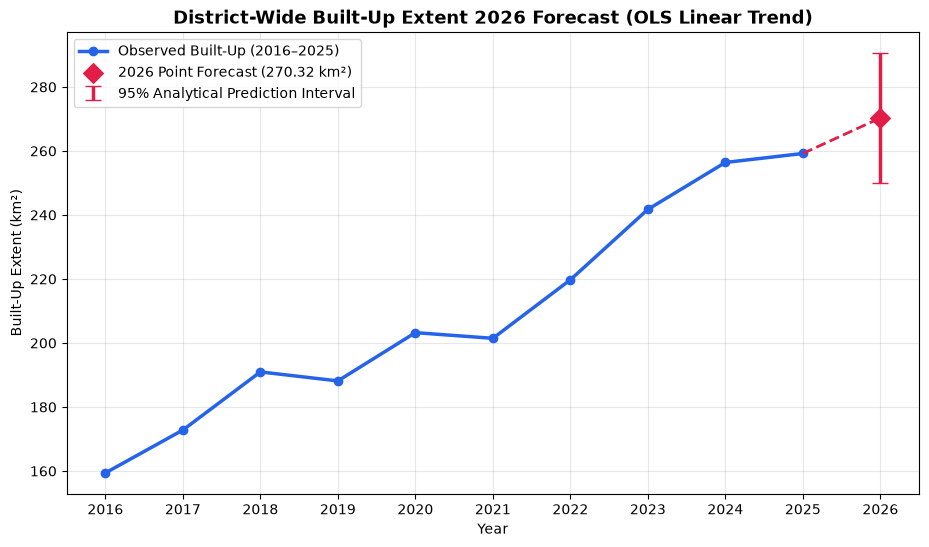

In [5]:
# Final Forecast Visualization
fc_total = df_fc[df_fc["target"].str.contains("Total Built-Up", case=False)].iloc[0]

plt.figure(figsize=(11, 6))
plt.plot(df_master["year"], df_master["built_up_km2"], marker="o", color="#2563eb", lw=2.5, label="Observed Built-Up (2016–2025)")

# Connect 2025 to 2026
plt.plot([2025, 2026], [df_master["built_up_km2"].iloc[-1], fc_total["point_forecast"]], color="#e11d48", linestyle="--", lw=2)
plt.scatter([2026], [fc_total["point_forecast"]], color="#e11d48", s=100, zorder=5, marker="D", label=f"2026 Point Forecast ({fc_total['point_forecast']:.2f} km²)")

# Error bar for 95% PI
plt.errorbar(
    [2026], [fc_total["point_forecast"]],
    yerr=[[fc_total["point_forecast"] - fc_total["lower_95"]], [fc_total["upper_95"] - fc_total["point_forecast"]]],
    fmt="none", ecolor="#e11d48", elinewidth=2.5, capsize=6, label="95% Analytical Prediction Interval"
)

plt.title("District-Wide Built-Up Extent 2026 Forecast (OLS Linear Trend)", fontsize=13, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Built-Up Extent (km²)")
plt.xticks(list(range(2016, 2027)))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()